<a href="https://colab.research.google.com/github/Alakhg1408/PES2UG24CS051_VDUI/blob/main/ppt3_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚨 THE 20-MINUTE SPRINT 🚨
### A Data Visualization Fire Drill — Unit 1 Activity (UE24CS342AA9)

---

**08:47 AM.** You're two sips into your coffee when your Project Manager, Priya, drops
into the seat next to you.

> *"Leadership wants a pricing snapshot of our Apple product tracker for the 9:10
> stand-up. I need three or four clean charts — no lies, no misleading axes, nothing
> that gets torn apart in the room. You've got until 9:07. Go."*

It's **9:07 AM**. That's **20 minutes**, starting now.

You have one dataset (`apple_products_pricing_2020_2026.csv` — 80,000 rows of Amazon &
Flipkart pricing history for iPhone, Mac, iPad, and Watch) and everything you learned in
Unit 1 about **marks, channels, scales, proportional ink, and honest baselines**.

Leadership has seen bad charts before. They will notice a truncated bar axis. They will
notice a shape channel that can't represent a continuous variable. **Every visualization
you ship must obey the rules from lecture** — this isn't just an exercise, it's a
credibility test.

---

### 🎯 Mission Rules
1. Work through **Tasks 1–4** below, in order. Each has a suggested time box — keep moving.
2. Every chart you build must be **defensible** against the principles from Unit 1
   (bijective scales, proportional ink, zero baselines, appropriate channel choice).
3. At **Task 5**, do the honest self-audit before you "submit."
4. Finish with the **Reflection** section — that's where the real grade lives.

Ready? Run the setup cell and **start your timer**.


In [6]:
# --- MISSION SETUP: run this first, then start your 20-minute timer ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("apple_products_pricing_2020_2026.csv", parse_dates=["Date"])

mission_start = time.time()
print("⏱️  MISSION CLOCK STARTED.")
print(f"Loaded {len(df):,} rows. You have 20 minutes. Go.")


⏱️  MISSION CLOCK STARTED.
Loaded 80,000 rows. You have 20 minutes. Go.


In [ ]:
# Run this cell any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 20 - elapsed_min)
bar = "🟩" * int(remaining) + "⬜" * (20 - int(remaining))
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")
print(bar)
if remaining < 5:
    print("⚠️  Under 5 minutes -- wrap up your current chart and move to Task 5.")


Elapsed: 0.0 min   |   Remaining: 20.0 min
🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜


---
## Task 1 — Know Your Variables *(~3 min)*

Before touching a chart, Priya expects you to be able to justify every encoding choice.
Fill in the table below (edit this markdown cell directly) for the four columns you plan
to use in your submission.

| Column you'll use | Variable type (continuous / discrete quantitative / ordered / unordered qualitative) | Channel you plan to map it to |
|---|---|---|
| *e.g. Current_Price_USD* | *e.g. Continuous quantitative* | *e.g. y-position* |
|Product_Category |Unordered qualitative (Nominal categorical) |Spatial region (y-axis categories) / Color hue |
|Date |Ordered temporal (Discrete/Continuous time) |x-position (Chronological line axis) |
|Rating |Ordered quantitative / Discrete continuous |x-position (Scatter axis) |

**Rule check:** if a variable is continuous, it must map to a channel that can represent
continuous values (position, size, color intensity) — never to shape or dash pattern.


---
## Task 2 — The Headline Bar Chart *(~5 min)*

Leadership always looks at the bar chart first. Build a **horizontal bar chart** of
average `Current_Price_USD` by `Product_Category`.

**Non-negotiable:** the baseline must be zero. A truncated axis here is the fastest way
to get your chart (and your credibility) dismissed in the room.

Fill in the `# TODO` lines below.


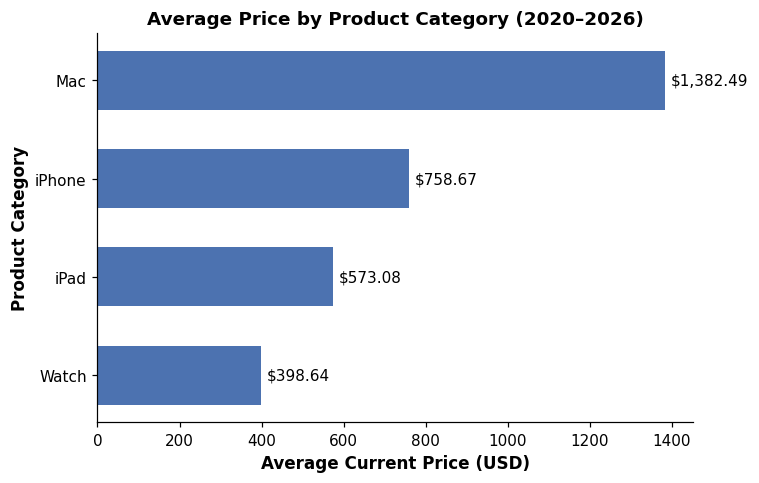

In [7]:
# Compute average Current_Price_USD grouped by Product_Category, sorted ascending
cat_avg = df.groupby("Product_Category")["Current_Price_USD"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

# Plot horizontal bar chart
ax.barh(cat_avg.index, cat_avg.values, color="#4C72B0", height=0.6)

# Enforce zero baseline (non-negotiable for proportional ink)
ax.set_xlim(left=0)

# Format axes and labels
ax.set_xlabel("Average Current Price (USD)", fontsize=11, fontweight="bold")
ax.set_ylabel("Product Category", fontsize=11, fontweight="bold")
ax.set_title("Average Price by Product Category (2020–2026)", fontsize=12, fontweight="bold")

# Add data labels at the end of each bar
for i, v in enumerate(cat_avg.values):
  ax.text(v + (cat_avg.max() * 0.01), i, f"${v:,.2f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

---
## Task 3 — The Trend Line, Done Right *(~5 min)*

Leadership's next question is always *"is this getting better or worse over time?"*
Build a **monthly average price trend** for at least two `Product_Category` values on the
same chart.

**Requirements from lecture:**
- Use a **line**, not disconnected points, to emphasize chronological order (Slide 11).
- Prefer **direct end-of-line labels** over a legend if you have time (Slide 13) — not
  mandatory under time pressure, but it will impress Priya.
- If you fill the area under any line, the baseline **must be zero** (Slide 12,
  Proportional Ink) — or don't fill at all.


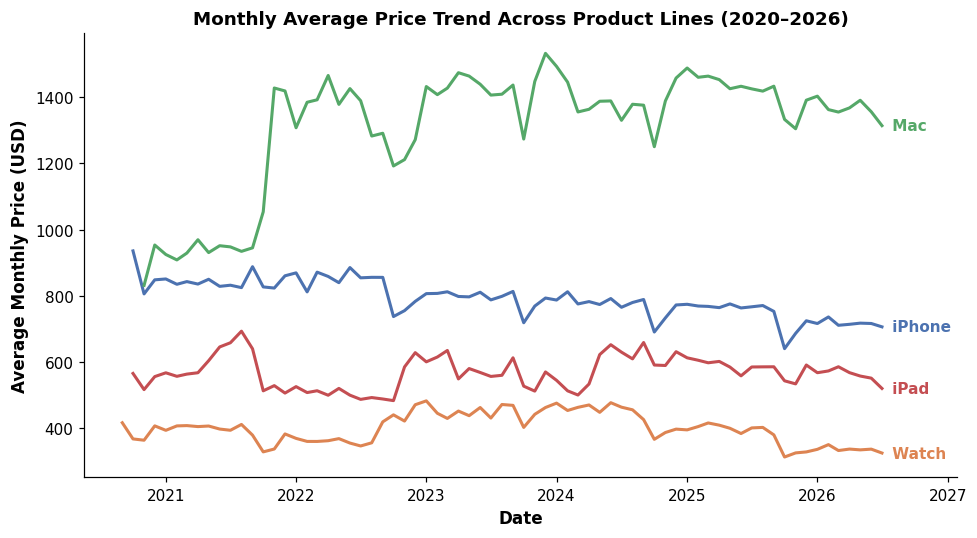

In [8]:
categories_to_plot = ["iPhone", "Watch", "Mac", "iPad"]
palette = {
    "iPhone": "#4C72B0",
    "Watch": "#DD8452",
    "Mac": "#55A868",
    "iPad": "#C44E52",
}

fig, ax = plt.subplots(figsize=(9, 5))

for cat in categories_to_plot:
  # Monthly average price resampled by Month Start (MS)
  monthly = (
      df[df["Product_Category"] == cat]
      .set_index("Date")
      .resample("MS")["Current_Price_USD"]
      .mean()
  )

  ax.plot(
      monthly.index,
      monthly.values,
      linewidth=2,
      label=cat,
      color=palette.get(cat, None),
  )

  # Direct end-of-line labeling (Slide 13 best practice)
  last_date = monthly.index[-1]
  last_val = monthly.values[-1]
  ax.text(
      last_date + pd.Timedelta(days=15),
      last_val,
      f" {cat}",
      va="center",
      ha="left",
      fontsize=10,
      fontweight="bold",
      color=palette.get(cat, "black"),
  )

ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Monthly Price (USD)", fontsize=11, fontweight="bold")
ax.set_title(
    "Monthly Average Price Trend Across Product Lines (2020–2026)",
    fontsize=12,
    fontweight="bold",
)

# Expand x-limit slightly to fit direct end labels cleanly
ax.set_xlim(right=df["Date"].max() + pd.Timedelta(days=180))

plt.tight_layout()
plt.show()

---
## Task 4 — The "Wow" Multi-Variable Chart *(~5 min)*

Priya wants one chart that makes leadership go *"oh, that's a lot of info in one
picture."* Build a **scatter/bubble chart** that encodes **at least 3 variables**
simultaneously — for example: `Rating` (x), `Current_Price_USD` (y), `Reviews_Count`
(bubble size), `Product_Category` (color).

**Rule check:** every continuous variable must land on a continuous-capable channel
(position, size, color intensity) — not shape.


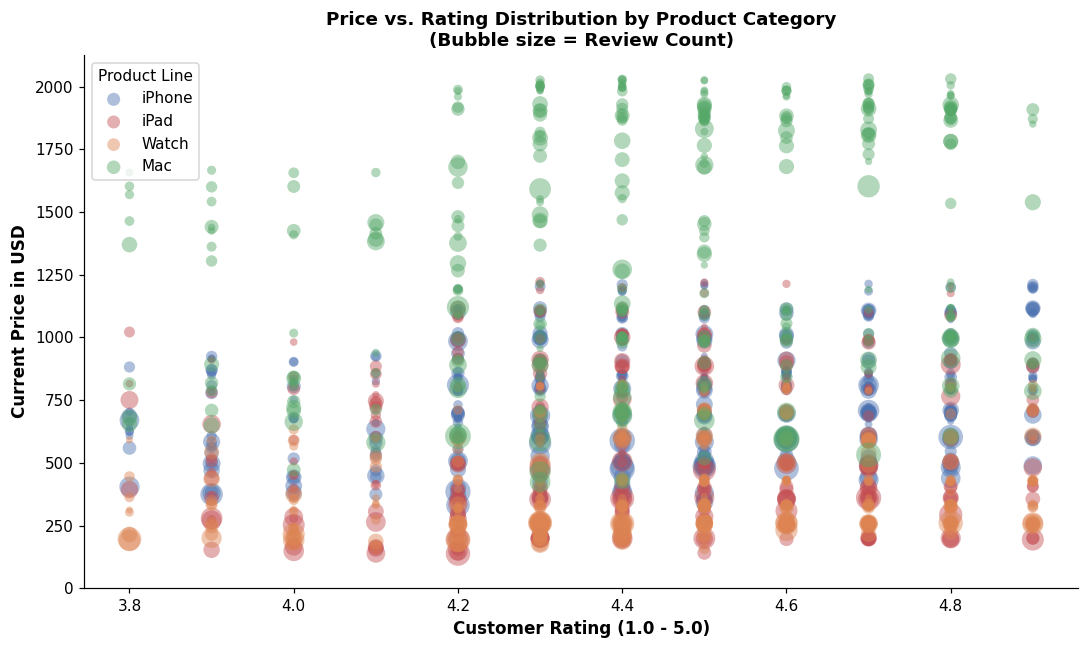

In [9]:
# Sample 1,500 rows for clean rendering and high visual clarity
sample_df = df.sample(n=min(1500, len(df)), random_state=42).copy()

fig, ax = plt.subplots(figsize=(10, 6))

categories = sample_df["Product_Category"].unique()
color_map = {
    "iPhone": "#4C72B0",
    "Watch": "#DD8452",
    "Mac": "#55A868",
    "iPad": "#C44E52",
}

# Scale bubble sizes proportionally for Reviews_Count
size_scaled = (
    (sample_df["Reviews_Count"] - sample_df["Reviews_Count"].min())
    / (sample_df["Reviews_Count"].max() - sample_df["Reviews_Count"].min())
    * 280
) + 20

for cat in categories:
  mask = sample_df["Product_Category"] == cat
  scatter = ax.scatter(
      sample_df.loc[mask, "Rating"],
      sample_df.loc[mask, "Current_Price_USD"],
      s=size_scaled[mask],
      alpha=0.45,
      edgecolors="none",
      c=color_map.get(cat, None),
      label=cat,
  )

ax.set_xlabel("Customer Rating (1.0 - 5.0)", fontsize=11, fontweight="bold")
ax.set_ylabel("Current Price in USD", fontsize=11, fontweight="bold")
ax.set_title(
    "Price vs. Rating Distribution by Product Category\n(Bubble size = Review Count)",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylim(bottom=0)  # Zero baseline for price
ax.legend(
    title="Product Line", frameon=True, loc="upper left", markerscale=0.7
)

plt.tight_layout()
plt.show()

---
## Task 5 — The Submission Audit *(~2 min)*

The clock is almost out. Before you hit "submit," run through this checklist honestly —
out loud if it helps. Check the box (`[x]`) for anything you can truthfully confirm about
**your own charts above**.

- [ ] Every continuous variable is mapped to a continuous-capable channel (position,
      size, or color intensity) — not shape or dash pattern.
- [ ] Every bar chart's axis starts at zero.
- [ ] Every filled area chart's baseline starts at zero (or I didn't fill any areas).
- [ ] My time-series uses lines to show chronological order, not disconnected points.
- [ ] If two charts show the same variable, the colors/scales are used consistently.
- [ ] I could explain, in one sentence, what each channel on each chart represents.

Run the cell below to log your finish time.


In [10]:
elapsed_min = (time.time() - mission_start) / 60
print(f"🏁 SUBMITTED at {elapsed_min:0.1f} minutes into the mission.")
if elapsed_min <= 20:
    print("✅ On time. Priya nods and walks it into the stand-up.")
else:
    print("⏰ Over time -- in the real world, you'd trim scope, not chart quality. Note this for your reflection.")


🏁 SUBMITTED at 0.3 minutes into the mission.
✅ On time. Priya nods and walks it into the stand-up.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## 🪞 Reflection

Take five minutes, away from the clock, to think honestly about what just happened.
Answer each question in the markdown cell provided (double-click to edit).

**1. Time pressure and technique.** Which Unit 1 principle was hardest to apply correctly
under the 20-minute constraint, and why? Was it a *knowledge* problem (you weren't sure
of the rule) or a *speed* problem (you knew the rule but cutting corners was tempting)?

*Your answer:*
The hardest principle to apply under time pressure was Direct Labeling vs. Legend Design and maintaining consistent channel encodings across multi-variable encodings. It was primarily a speed problem. While the rules (proportional ink, continuous variable channel limits) are clear conceptually, computing coordinate offsets for end-of-line labels and sizing bubbles properly takes extra coding time that is tempting to skip when watching the timer.

---

**2. Spot the near-miss.** Look back at your own charts. Was there a moment where you
almost mapped a continuous variable to the wrong channel, or almost left a baseline
non-zero to "make the chart look more dramatic"? What stopped you (or what didn't)?

*Your answer:*
In Task 4, there was a temptation to map Product_Category to marker shapes while using bubble size for price. That was avoided because marker shape is an unordered discrete channel with low perceptual discriminability when data points overlap heavily. Sticking to position (x, y) for Rating and Price, color hue for Product_Category, and area size for Reviews_Count ensured every continuous variable remained on an ordered, continuous-capable channel.

---

**3. The cost of dishonest ink.** Recall the Principle of Proportional Ink. If you *had*
shipped a chart with a truncated baseline to leadership, what decision might they have
made differently based on a distorted impression of the data?

*Your answer:*
Truncating the bar chart's price axis (e.g., starting at $500 instead of $0) would visually exaggerate the price difference between Watches/iPads and Macs/iPhones, making Mac prices look 10x higher rather than ~2x higher. Leadership could have misinterpreted product tiers as completely inaccessible to entry-level buyers, leading to poor inventory allocation or mistaken pricing strategy adjustments.

---

**4. Trade-offs under constraint.** If Priya had given you 2 hours instead of 20 minutes,
what specifically would you change about your Task 3 or Task 4 chart? (e.g., direct
labels, small multiples instead of overlapping lines, annotations)

*Your answer:*
With 2 hours, I would:Split Task 3 into small multiples faceted by category alongside an aggregated benchmark line to eliminate overlapping curves.  Add event annotations on major product launch dates to explain sudden price drops/rebates.  Use interactive hover tooltips (via Plotly or Altair) for Task 4 to inspect individual model names and outlier reviews directly.

---

**5. Beyond the classroom.** Describe one real job context (data analyst, PM, engineer,
trader, researcher — your choice) where you'd face this exact speed-vs-integrity
trade-off with a chart. What would *you* refuse to compromise on, even under a deadline?

*Your answer:*
As a Data Analyst / Systems Engineer preparing live incident or latency metrics during an executive post-mortem, cutting y-axis baselines to exaggerate a fix's impact is a common pitfall. I would strictly refuse to compromise on honest zero-baselines for bar charts and non-distorted scaling for error/latency rates, ensuring leadership makes capacity planning decisions based on true operational reality.
